# Modelagem com Regressão Logística

Objetivos:
- treinar um baseline de regressao logistica usando `credit_score_features.csv`
- avaliar performance inicial
- investigar colinearidade e redundancia entre features
- entender quando vale remover variaveis
- comparar baseline sem PCA vs. uma versao com PCA nas variaveis numericas


## 1. Objetivo

- `03_modeling_logreg.ipynb` avalia a primeira estrategia de modelagem e ajuda a decidir sobre selecao de features e PCA para o modelo de regressão logística

In [11]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', 200)

In [12]:
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'credit_score_features.csv'
df = pd.read_csv(DATA_PATH)

print(f'Caminho: {DATA_PATH.resolve()}')
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
df.head()

Caminho: C:\Users\guilh\repos_github\credit-scoring-model\data\processed\credit_score_features.csv
Shape: 100,000 linhas x 35 colunas


,Customer_ID,Month,Month_Num,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,target,Loan_Type_Count,Has_Min_Payment_Only,Is_Bad_Credit_Mix,Debt_to_Income_Ratio,EMI_to_Income_Ratio,Invested_to_Income_Ratio,Balance_to_Income_Ratio,Delay_x_Inquiries,Utilization_x_Debt
0,CUS_0x1000,January,1,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",62,25,1.63,10,Bad,1562.91,26.612093,122,Yes,42.94109,244.750283,Low_spent_Large_value_payments,252.924793,0,2,1,1,0.051032,0.015868,0.090442,0.093463,620,41592.306407
1,CUS_0x1000,February,2,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",62,23,1.63,11,Bad,1562.91,29.439759,123,Yes,42.94109,176.132567,High_spent_Small_value_payments,311.542510,1,2,1,1,0.051032,0.015868,0.065086,0.115123,682,46011.693758
2,CUS_0x1000,March,3,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",62,28,1.63,11,Bad,1562.91,38.285928,124,Yes,42.94109,109.056519,High_spent_Medium_value_payments,368.618557,1,2,1,1,0.051032,0.015868,0.040299,0.136215,682,59837.459708
3,CUS_0x1000,April,4,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",64,25,1.63,11,Bad,1562.91,32.843081,125,Yes,42.94109,87.909909,High_spent_Medium_value_payments,419.765167,1,2,1,1,0.051032,0.015868,0.032485,0.155115,704,51330.780120
4,CUS_0x1000,May,5,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",67,25,2.63,11,Bad,1562.91,32.330508,126,Yes,42.94109,191.834767,Low_spent_Large_value_payments,305.840309,1,2,1,1,0.051032,0.015868,0.070888,0.113016,737,50529.674519


## 2. Definindo a base de modelagem

Para treinar a regressao logistica:
- `target` sera a variavel resposta
- `Customer_ID` sera usado apenas para separacao por grupo, evitando que meses do mesmo cliente caiam em treino e teste ao mesmo tempo
- `Customer_ID` nao entra como feature do modelo
- variaveis categoricas serao codificadas com one-hot encoding
- variaveis numericas serao padronizadas


In [13]:
target_col = 'target'
group_col = 'Customer_ID'
drop_from_model = ['Customer_ID', 'target']

X = df.drop(columns=drop_from_model)
y = df[target_col]
groups = df[group_col]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print('Variaveis numericas:', len(numeric_cols))
print('Variaveis categoricas:', len(categorical_cols))
print('Categoricas:', categorical_cols)

Variaveis numericas: 27
Variaveis categoricas: 6
Categoricas: ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


C:\Users\guilh\AppData\Local\Temp\ipykernel_21220\3229967435.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [14]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
dev_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_dev, X_test = X.iloc[dev_idx].copy(), X.iloc[test_idx].copy()
y_dev, y_test = y.iloc[dev_idx].copy(), y.iloc[test_idx].copy()
groups_dev, groups_test = groups.iloc[dev_idx], groups.iloc[test_idx]

val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(val_splitter.split(X_dev, y_dev, groups=groups_dev))

X_train, X_val = X_dev.iloc[train_idx].copy(), X_dev.iloc[val_idx].copy()
y_train, y_val = y_dev.iloc[train_idx].copy(), y_dev.iloc[val_idx].copy()
groups_train, groups_val = groups_dev.iloc[train_idx], groups_dev.iloc[val_idx]

print('Clientes no treino:', groups_train.nunique())
print('Clientes na validacao:', groups_val.nunique())
print('Clientes no teste:', groups_test.nunique())
print('Intersecao treino-validacao:', len(set(groups_train).intersection(set(groups_val))))
print('Intersecao treino-teste:', len(set(groups_train).intersection(set(groups_test))))
print('Intersecao validacao-teste:', len(set(groups_val).intersection(set(groups_test))))
print('Shape treino:', X_train.shape)
print('Shape validacao:', X_val.shape)
print('Shape teste:', X_test.shape)

Clientes no treino: 7500
Clientes na validacao: 2500
Clientes no teste: 2500
Intersecao treino-validacao: 0
Intersecao treino-teste: 0
Intersecao validacao-teste: 0
Shape treino: (60000, 33)
Shape validacao: (20000, 33)
Shape teste: (20000, 33)


## 3. Baseline de regressao logistica

Primeiro treinamos um baseline simples e robusto. Agora tambem reservamos uma base de validacao por grupo para calibrar threshold e testar ajustes voltados para a classe 1 sem vazar informacao do teste.

In [15]:
def build_preprocessor(
    use_pca=False,
    n_components=0.95,
    min_frequency=None,
    numeric_features=None,
    categorical_features=None
):
    numeric_features = numeric_cols if numeric_features is None else numeric_features
    categorical_features = categorical_cols if categorical_features is None else categorical_features

    numeric_steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
    if use_pca:
        numeric_steps.append(('pca', PCA(n_components=n_components, random_state=42)))

    numeric_transformer = Pipeline(steps=numeric_steps)
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=min_frequency))
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )


def build_model(
    use_pca=False,
    n_components=0.95,
    C=1.0,
    class_weight=None,
    min_frequency=None,
    numeric_features=None,
    categorical_features=None
):
    return Pipeline(steps=[
        (
            'preprocessor',
            build_preprocessor(
                use_pca=use_pca,
                n_components=n_components,
                min_frequency=min_frequency,
                numeric_features=numeric_features,
                categorical_features=categorical_features
            )
        ),
        ('model', LogisticRegression(max_iter=2000, solver='lbfgs', C=C, class_weight=class_weight))
    ])


def find_best_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1_scores = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1_scores))
    return float(thresholds[best_idx]), pd.DataFrame({
        'threshold': thresholds,
        'precision': precision[:-1],
        'recall': recall[:-1],
        'f1': f1_scores
    })


def summarize_class_1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
        'accuracy': report['accuracy']
    }


def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5):
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    train_proba = fitted.predict_proba(X_train)[:, 1]
    test_proba = fitted.predict_proba(X_test)[:, 1]
    train_pred = (train_proba >= threshold).astype(int)
    test_pred = (test_proba >= threshold).astype(int)

    metrics = {
        'threshold': threshold,
        'train_auc': roc_auc_score(y_train, train_proba),
        'test_auc': roc_auc_score(y_test, test_proba),
        'train_pr_auc': average_precision_score(y_train, train_proba),
        'test_pr_auc': average_precision_score(y_test, test_proba),
        'train_accuracy': accuracy_score(y_train, train_pred),
        'test_accuracy': accuracy_score(y_test, test_pred)
    }
    return fitted, metrics, train_pred, test_pred, train_proba, test_proba

In [16]:
baseline_model = build_model(use_pca=False)
baseline_fitted, baseline_metrics, baseline_train_pred, baseline_pred, baseline_train_proba, baseline_proba = evaluate_model(
    baseline_model, X_train, y_train, X_test, y_test, threshold=0.5
)

pd.DataFrame([baseline_metrics]).round(4)

,threshold,train_auc,test_auc,train_pr_auc,test_pr_auc,train_accuracy,test_accuracy
0,0.5,0.9148,0.8066,0.8249,0.5971,0.8749,0.7759


              precision    recall  f1-score   support

           0     0.8213    0.8768    0.8481     14274
           1     0.6306    0.5244    0.5727      5726

    accuracy                         0.7759     20000
   macro avg     0.7260    0.7006    0.7104     20000
weighted avg     0.7667    0.7759    0.7693     20000



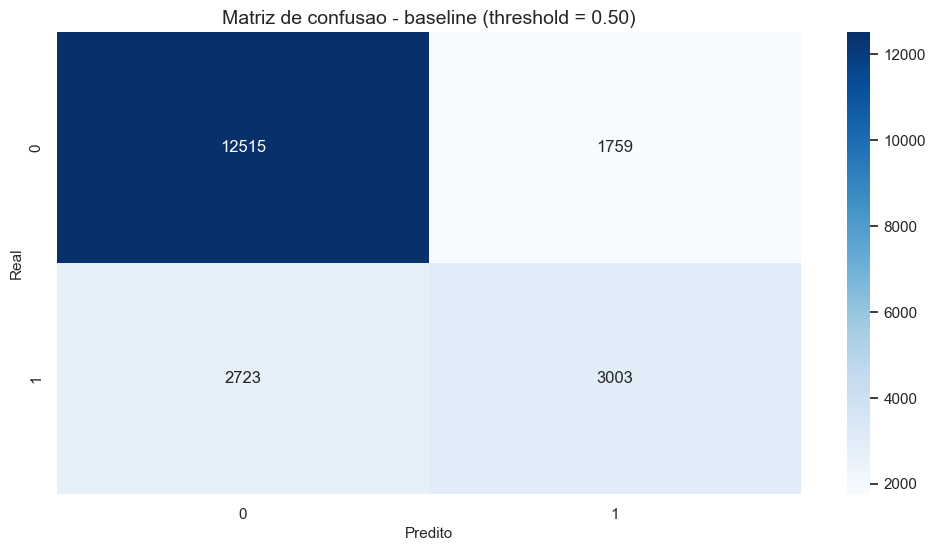

In [17]:
print(classification_report(y_test, baseline_pred, digits=4, zero_division=0))
cm = confusion_matrix(y_test, baseline_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusao - baseline (threshold = 0.50)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

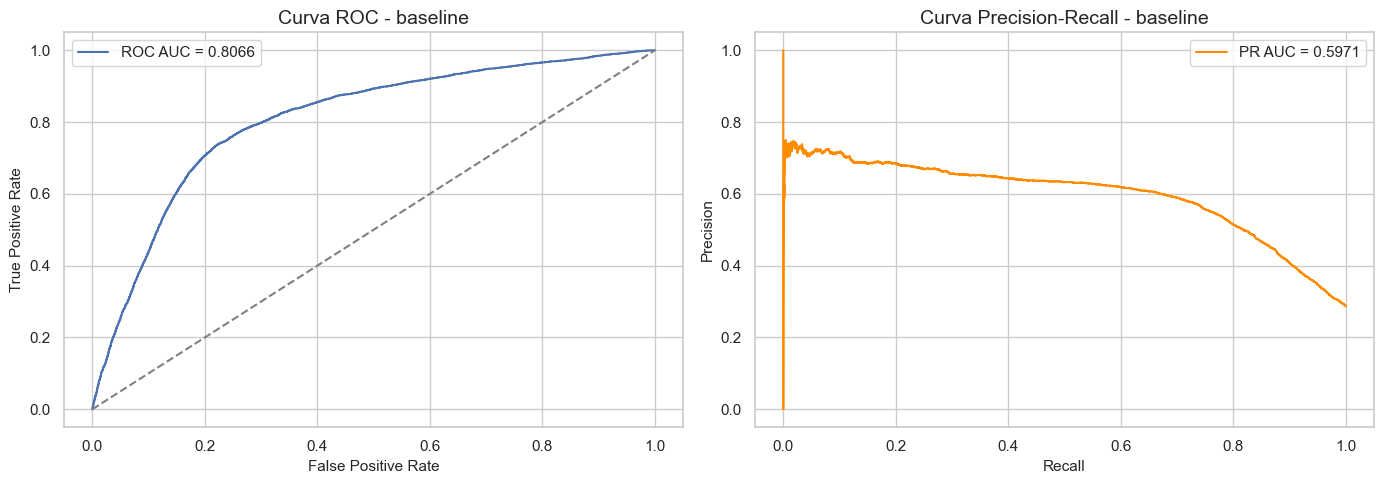

In [18]:
fpr, tpr, _ = roc_curve(y_test, baseline_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, baseline_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f'ROC AUC = {baseline_metrics["test_auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('Curva ROC - baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color='darkorange', label=f'PR AUC = {baseline_metrics["test_pr_auc"]:.4f}')
axes[1].set_title('Curva Precision-Recall - baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Explorando alternativas para tentar melhorar desempenho na classe 1 da target

A regressao logistica baseline usa threshold fixo de 0.50 e trata todas as categorias raras de `Type_of_Loan` separadamente. Aqui testamos tres alavancas que costumam ajudar quando a classe positiva perde recall e F1:

- calibracao de threshold usando a base de validacao
- `class_weight='balanced'` para dar mais peso a erros na classe 1
- agrupamento de categorias raras com `min_frequency` no one-hot encoding

Importante: a validacao e separada por `Customer_ID`, entao escolhemos threshold e hiperparametros sem usar a base de teste.

In [19]:
baseline_val_proba = baseline_fitted.predict_proba(X_val)[:, 1]
baseline_best_threshold, baseline_threshold_df = find_best_threshold(y_val, baseline_val_proba)
baseline_tuned_pred = (baseline_proba >= baseline_best_threshold).astype(int)

improved_model = build_model(use_pca=False, C=0.5, class_weight='balanced', min_frequency=50)
improved_fitted, improved_metrics, improved_train_pred, improved_pred_default, improved_train_proba, improved_proba = evaluate_model(
    improved_model, X_train, y_train, X_test, y_test, threshold=0.5
)

improved_val_proba = improved_fitted.predict_proba(X_val)[:, 1]
improved_best_threshold, improved_threshold_df = find_best_threshold(y_val, improved_val_proba)
improved_pred_tuned = (improved_proba >= improved_best_threshold).astype(int)

comparison_class1_df = pd.DataFrame([
    {
        'model': 'baseline_default_050',
        **baseline_metrics,
        **summarize_class_1(y_test, baseline_pred)
    },
    {
        'model': 'baseline_threshold_tuned',
        **{**baseline_metrics, 'threshold': baseline_best_threshold},
        **summarize_class_1(y_test, baseline_tuned_pred)
    },
    {
        'model': 'balanced_minfreq50_default_050',
        **improved_metrics,
        **summarize_class_1(y_test, improved_pred_default)
    },
    {
        'model': 'balanced_minfreq50_threshold_tuned',
        **{**improved_metrics, 'threshold': improved_best_threshold},
        **summarize_class_1(y_test, improved_pred_tuned)
    }
]).round(4)

comparison_class1_df[['model', 'threshold', 'test_auc', 'test_pr_auc', 'test_accuracy', 'precision_1', 'recall_1', 'f1_1']]

,model,threshold,test_auc,test_pr_auc,test_accuracy,precision_1,recall_1,f1_1
0,baseline_default_050,0.5000,0.8066,0.5971,0.7759,0.6306,0.5244,0.5727
1,baseline_threshold_tuned,0.2837,0.8066,0.5971,0.7759,0.5699,0.7377,0.6430
2,balanced_minfreq50_default_050,0.5000,0.8186,0.6164,0.7741,0.5817,0.7510,0.6556
3,balanced_minfreq50_threshold_tuned,0.4990,0.8186,0.6164,0.7741,0.5807,0.7511,0.6550


Threshold escolhido no modelo ajustado: 0.4990
              precision    recall  f1-score   support

           0     0.8869    0.7825    0.8314     14274
           1     0.5807    0.7511    0.6550      5726

    accuracy                         0.7735     20000
   macro avg     0.7338    0.7668    0.7432     20000
weighted avg     0.7992    0.7735    0.7809     20000



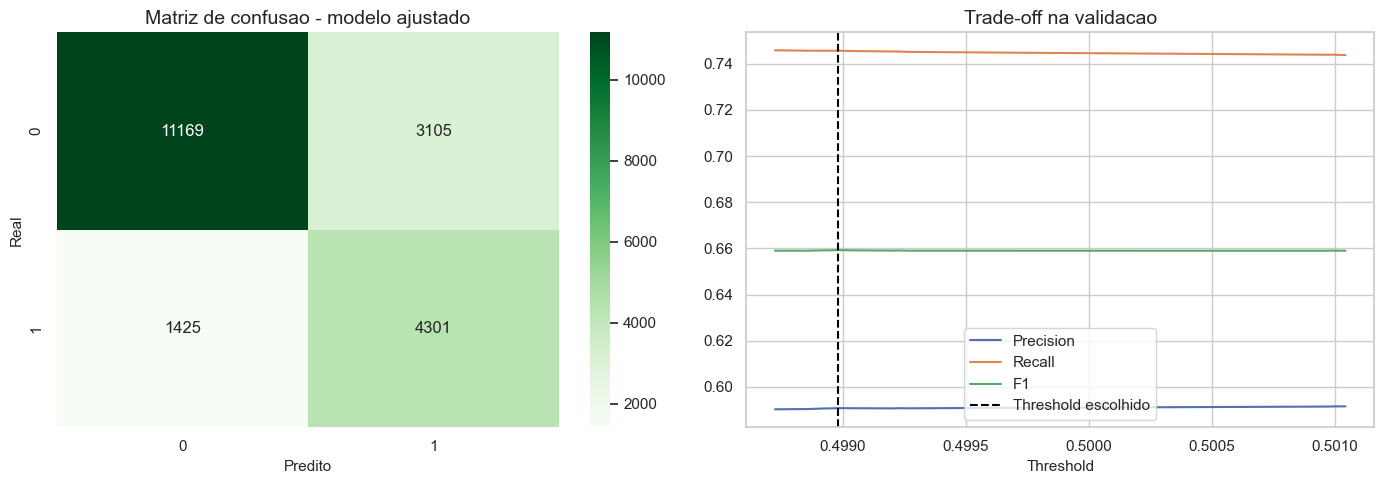

In [20]:
print(f'Threshold escolhido no modelo ajustado: {improved_best_threshold:.4f}')
print(classification_report(y_test, improved_pred_tuned, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, improved_pred_tuned), annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Matriz de confusao - modelo ajustado')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

top_thresholds = improved_threshold_df.sort_values('f1', ascending=False).head(15).sort_values('threshold')
axes[1].plot(top_thresholds['threshold'], top_thresholds['precision'], label='Precision')
axes[1].plot(top_thresholds['threshold'], top_thresholds['recall'], label='Recall')
axes[1].plot(top_thresholds['threshold'], top_thresholds['f1'], label='F1')
axes[1].axvline(improved_best_threshold, color='black', linestyle='--', label='Threshold escolhido')
axes[1].set_title('Trade-off na validacao')
axes[1].set_xlabel('Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. PCA ou remoção de features é interessante nesse projeto?

Algumas pistas:
- pares de variaveis muito correlacionadas
- VIF alto em variaveis numericas
- coeficientes instaveis ou muito redundantes
- pouca melhora preditiva ao adicionar conjuntos de features

Abaixo fazemos os dois primeiros diagnosticos de forma direta.

### O que é VIF ?

O VIF (Variance Inflation Factor ou Fator de Inflação da Variância) é uma medida estatística usada em Data Science para detectar a multicolinearidade em modelos de regressão. Ele quantifica o quanto a variância de um coeficiente de regressão estimado é aumentada devido à correlação entre variáveis independentes.

- Objetivo: Identificar se variáveis preditoras (features) são muito semelhantes entre si, o que pode tornar o modelo instável e difícil de interpretar.

- Interpretação:   
1. VIF perto de 1: pouca colinearidade
2. VIF acima de 5: atencao
3. VIF acima de 10: forte candidato a revisao ou remocao

- Fórmula:

O VIF é calculado como:
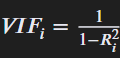
onde R^2 é o coeficiente de determinação da regressão da variável contra as outras variáveis.

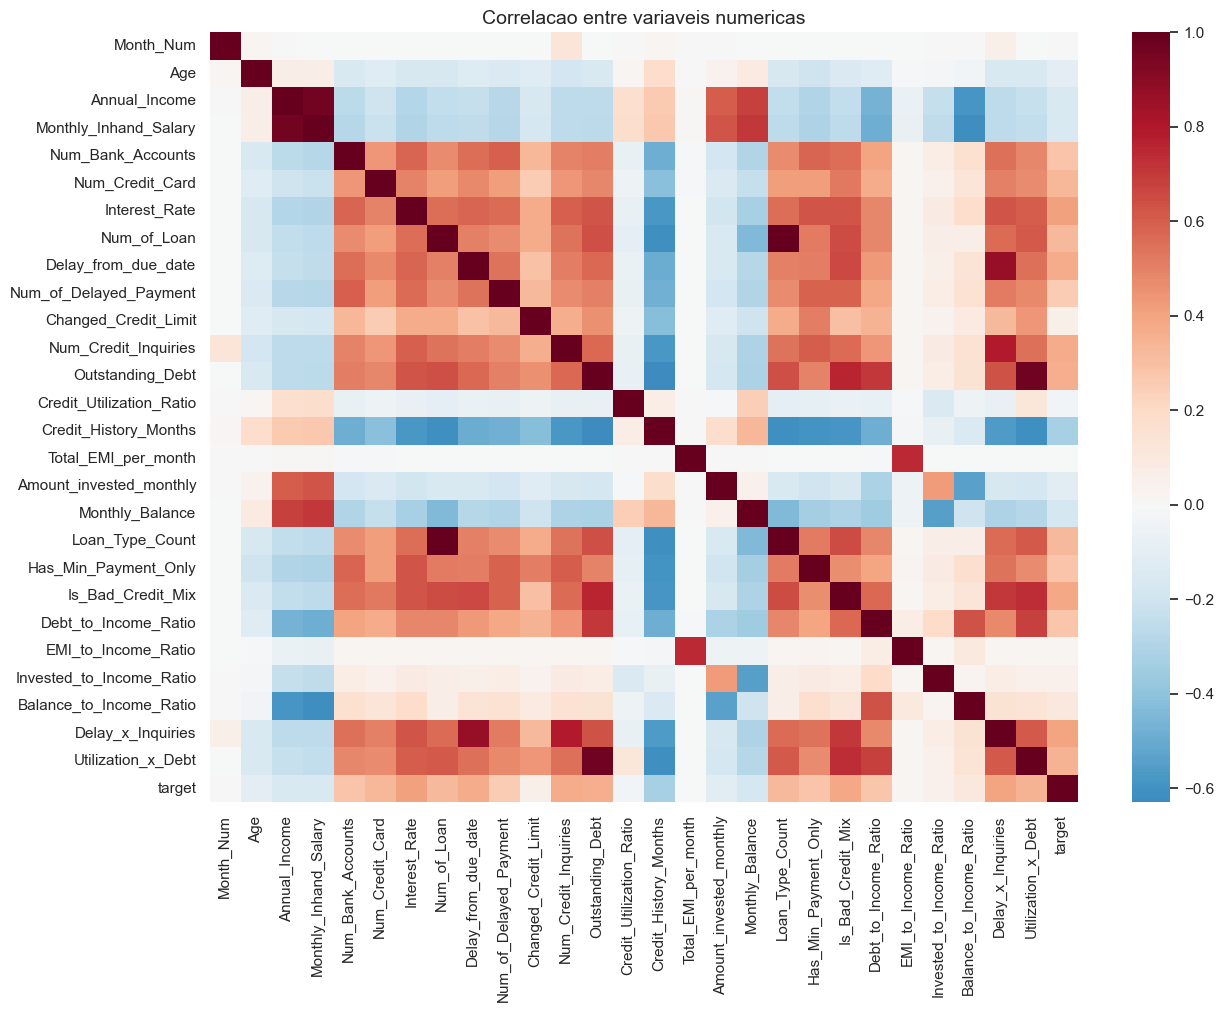

In [21]:
corr_matrix = df[numeric_cols + ['target']].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0)
plt.title('Correlacao entre variaveis numericas')
plt.show()

In [22]:
corr_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feature_1', 'feature_2', 'abs_corr']
corr_pairs.sort_values('abs_corr', ascending=False).head(20)

,feature_1,feature_2,abs_corr
214,Num_of_Loan,Loan_Type_Count,0.999295
362,Outstanding_Debt,Utilization_x_Debt,0.969345
59,Annual_Income,Monthly_Inhand_Salary,0.959118
249,Delay_from_due_date,Delay_x_Inquiries,0.870144
333,Num_Credit_Inquiries,Delay_x_Inquiries,0.785357
356,Outstanding_Debt,Is_Bad_Credit_Mix,0.760932
442,Total_EMI_per_month,EMI_to_Income_Ratio,0.739788
586,Is_Bad_Credit_Mix,Utilization_x_Debt,0.733798
101,Monthly_Inhand_Salary,Monthly_Balance,0.706746
585,Is_Bad_Credit_Mix,Delay_x_Inquiries,0.706661


In [23]:
def compute_vif(dataframe):
    results = []
    work = dataframe.copy()
    work = work.fillna(work.median(numeric_only=True))

    for col in work.columns:
        X_aux = work.drop(columns=[col])
        y_aux = work[col]
        model = LinearRegression()
        model.fit(X_aux, y_aux)
        r2 = model.score(X_aux, y_aux)
        vif = np.inf if r2 >= 0.9999 else 1 / (1 - r2)
        results.append({'feature': col, 'r2_against_others': r2, 'vif': vif})

    return pd.DataFrame(results).sort_values('vif', ascending=False)


vif_df = compute_vif(df[numeric_cols])
vif_df.head(20).round(4)

,feature,r2_against_others,vif
18,Loan_Type_Count,0.9986,711.4849
7,Num_of_Loan,0.9986,709.9593
12,Outstanding_Debt,0.9782,45.9273
26,Utilization_x_Debt,0.9761,41.8605
3,Monthly_Inhand_Salary,0.9605,25.3457
25,Delay_x_Inquiries,0.9216,12.7541
2,Annual_Income,0.9204,12.5662
8,Delay_from_due_date,0.8632,7.3100
16,Amount_invested_monthly,0.8572,7.0026
17,Monthly_Balance,0.8545,6.8730


## 6. O que a regressao logistica esta aprendendo?

Agora olhamos os coeficientes do baseline. Isso ajuda a entender quais variaveis estao puxando o score para inadimplencia ou para adimplencia.

In [24]:
X_train_transformed = baseline_fitted.named_steps['preprocessor'].transform(X_train)
feature_names = baseline_fitted.named_steps['preprocessor'].get_feature_names_out()

X_train_transformed_df = pd.DataFrame.sparse.from_spmatrix(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

X_train_transformed_df.head()


,num__Month_Num,num__Age,num__Annual_Income,num__Monthly_Inhand_Salary,num__Num_Bank_Accounts,num__Num_Credit_Card,num__Interest_Rate,num__Num_of_Loan,num__Delay_from_due_date,num__Num_of_Delayed_Payment,num__Changed_Credit_Limit,num__Num_Credit_Inquiries,num__Outstanding_Debt,num__Credit_Utilization_Ratio,num__Credit_History_Months,num__Total_EMI_per_month,num__Amount_invested_monthly,num__Monthly_Balance,num__Loan_Type_Count,num__Has_Min_Payment_Only,num__Is_Bad_Credit_Mix,num__Debt_to_Income_Ratio,num__EMI_to_Income_Ratio,num__Invested_to_Income_Ratio,num__Balance_to_Income_Ratio,num__Delay_x_Inquiries,num__Utilization_x_Debt,cat__Month_April,cat__Month_August,cat__Month_February,cat__Month_January,cat__Month_July,cat__Month_June,cat__Month_March,cat__Month_May,cat__Occupation_Accountant,cat__Occupation_Architect,cat__Occupation_Developer,cat__Occupation_Doctor,cat__Occupation_Engineer,cat__Occupation_Entrepreneur,cat__Occupation_Journalist,cat__Occupation_Lawyer,cat__Occupation_Manager,cat__Occupation_Mechanic,cat__Occupation_Media_Manager,cat__Occupation_Musician,cat__Occupation_Scientist,cat__Occupation_Teacher,cat__Occupation_Writer,cat__Type_of_Loan_Auto Loan,"cat__Type_of_Loan_Auto Loan, Auto Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Auto Loan, Credit-Builder Loan, Credit-Builder Loan, Mortgage Loan, Personal Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Credit-Builder Loan, Payday Loan, Not Specified, Payday Loan, Student Loan, Debt Consolidation Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Home Equity Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Not Specified","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Not Specified, Debt Consolidation Loan, Credit-Builder Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Not Specified, Home Equity Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Personal Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Auto Loan, Personal Loan, Student Loan, Not Specified","cat__Type_of_Loan_Auto Loan, Auto Loan, Credit-Builder Loan, Credit-Builder Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Credit-Builder Loan, Debt Consolidation Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Credit-Builder Loan, Not Specified, Not Specified, Not Specified","cat__Type_of_Loan_Auto Loan, Auto Loan, Credit-Builder Loan, Personal Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Credit-Builder Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Home Equity Loan, Payday Loan, Credit-Builder Loan, Credit-Builder Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Not Specified","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Payday Loan, Debt Consolidation Loan, Debt Consolidation Loan, Not Specified","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Payday Loan, Mortgage Loan, Credit-Builder Loan, Auto Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Payday Loan, Payday Loan, Credit-Builder Loan, Not Specified","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Payday Loan, Payday Loan, Personal Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Debt Consolidation Loan, Student Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Home Equity Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Home Equity Loan, Credit-Builder Loan, Mortgage Loan, Payday Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Home Equity Loan, Home Equity Loan, Personal Loan, Payday Loan, Personal Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Home Equity Loan, Student Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Home Equity Loan, Student Loan, Home Equity Loan, Auto Loan, Mortgage Loan, Home Equity Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Mortgage Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Mortgage Loan, Auto Loan","cat__Type_of_Loan_Auto Loan, Auto Loan, Mortgage Loan, Mortgage Loan",

In [25]:
feature_names = baseline_fitted.named_steps['preprocessor'].get_feature_names_out()
coef_values = baseline_fitted.named_steps['model'].coef_.ravel()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef_values,
    'abs_coefficient': np.abs(coef_values)
}).sort_values('abs_coefficient', ascending=False)

coef_df.head(25)

,feature,coefficient,abs_coefficient
2501,"cat__Type_of_Loan_Not Specified, Mortgage Loan...",3.089838,3.089838
2247,"cat__Type_of_Loan_Mortgage Loan, Student Loan,...",3.035921,3.035921
2580,"cat__Type_of_Loan_Not Specified, Payday Loan, ...",2.998998,2.998998
2044,"cat__Type_of_Loan_Mortgage Loan, Mortgage Loan...",2.941831,2.941831
1506,"cat__Type_of_Loan_Home Equity Loan, Debt Conso...",2.926260,2.926260
3009,"cat__Type_of_Loan_Payday Loan, Not Specified, ...",2.921684,2.921684
2112,"cat__Type_of_Loan_Mortgage Loan, Not Specified...",2.918257,2.918257
3276,"cat__Type_of_Loan_Personal Loan, Credit-Builde...",2.853621,2.853621
1692,"cat__Type_of_Loan_Home Equity Loan, Not Specif...",2.811364,2.811364
1134,"cat__Type_of_Loan_Debt Consolidation Loan, Hom...",2.810636,2.810636


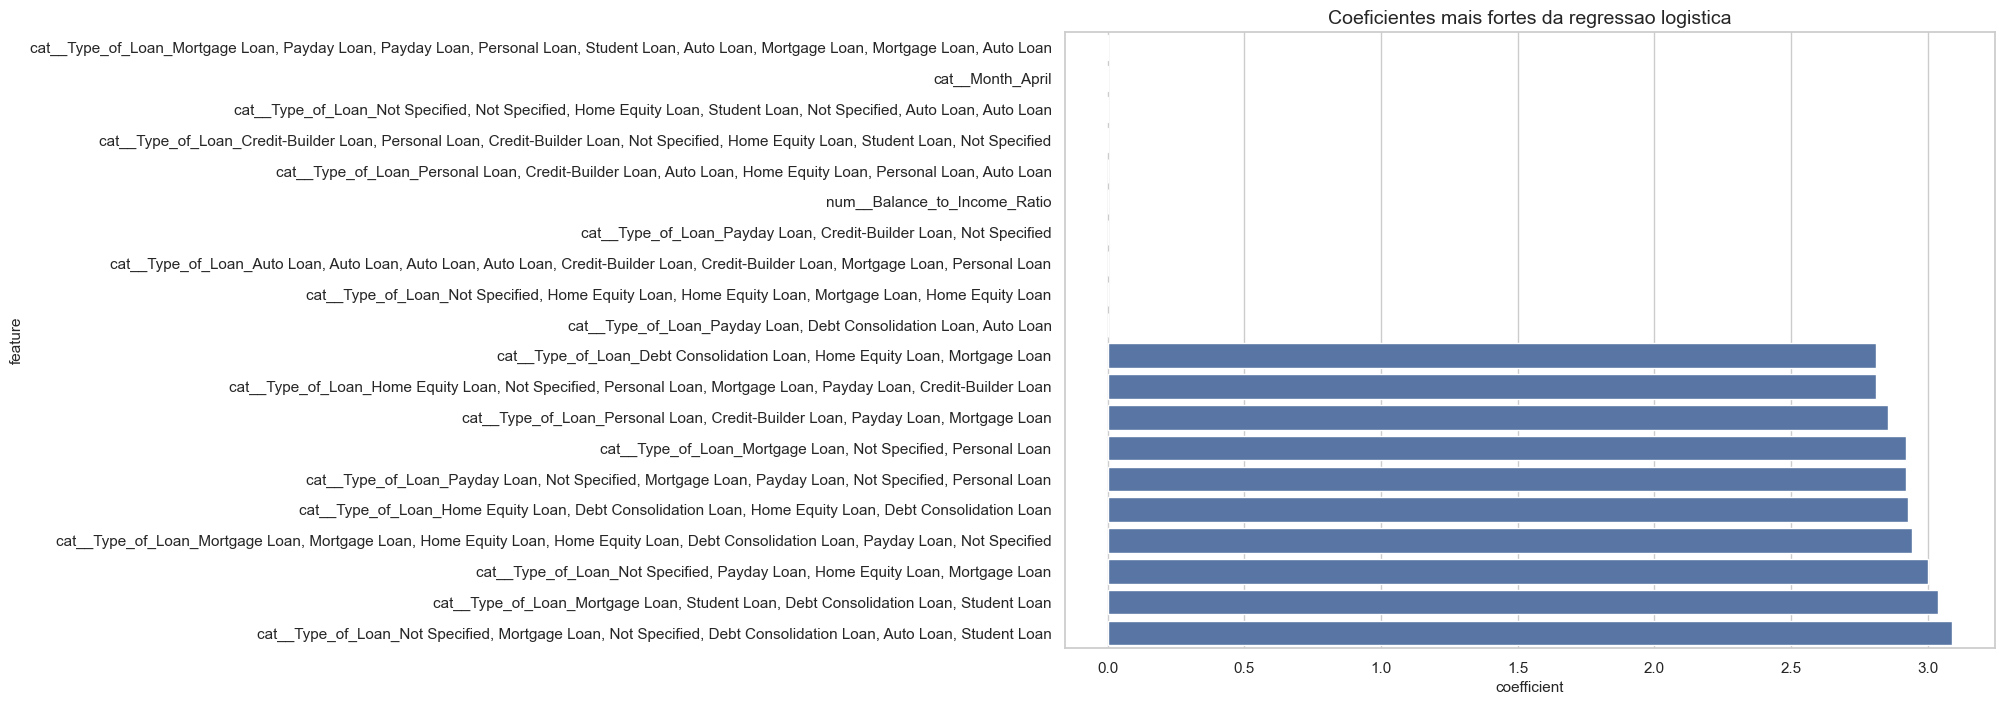

In [26]:
top_coef = pd.concat([coef_df.head(10), coef_df.tail(10)]).drop_duplicates()
plt.figure(figsize=(12, 8))
sns.barplot(data=top_coef.sort_values('coefficient'), x='coefficient', y='feature')
plt.title('Coeficientes mais fortes da regressao logistica')
plt.show()

## 7. Devemos remover features neste projeto?

Features candidatas a remoção:
- duas ou mais trazem praticamente a mesma informacao
- alguma apresenta VIF muito alto
- a feature tem coeficiente muito pequeno e pouca utilidade pratica

A seguir, vamos comparar performance com e sem o bloco de variaveis em questao.

In [27]:
candidate_drop = [
    'Loan_Type_Count',
    'Num_of_Loan',
    'Outstanding_Debt',
    'Utilization_x_Debt',
    'Monthly_Inhand_Salary',
    'Delay_x_Inquiries',
    'Annual_Income',
    'Delay_from_due_date',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Debt_to_Income_Ratio',
    'Num_Credit_Inquiries',
    'Balance_to_Income_Ratio',
    'Is_Bad_Credit_Mix',
    'Invested_to_Income_Ratio',
    'Has_Min_Payment_Only',
    'Credit_Utilization_Ratio',
    'Interest_Rate',
    'EMI_to_Income_Ratio',
    'Total_EMI_per_month'
]

X_train_reduced = X_train.drop(columns=candidate_drop)
X_test_reduced = X_test.drop(columns=candidate_drop)

numeric_cols_reduced = [col for col in X_train_reduced.columns if col not in categorical_cols]
categorical_cols_reduced = [col for col in X_train_reduced.columns if col in categorical_cols]

def build_reduced_model():
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols_reduced),
            ('cat', categorical_transformer, categorical_cols_reduced)
        ]
    )
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=2000, solver='lbfgs'))
    ])

reduced_model = build_reduced_model()
_, reduced_metrics, _, _, _, _ = evaluate_model(reduced_model, X_train_reduced, y_train, X_test_reduced, y_test)

comparison_df = pd.DataFrame([
    {'model': 'baseline', **baseline_metrics},
    {'model': 'reduced_features', **reduced_metrics}
]).round(4)
comparison_df

,model,threshold,train_auc,test_auc,train_pr_auc,test_pr_auc,train_accuracy,test_accuracy
0,baseline,0.5,0.9148,0.8066,0.8249,0.5971,0.8749,0.7759
1,reduced_features,0.5,0.9046,0.7703,0.8216,0.5547,0.8680,0.7498


Verifiquei a remoção das features com vifs mais altos apenas, e das com valor acima de 5, e o resultado foi muito parecido ou até piorado um pouco, o que mostra que são features que apesar com VIF alto, não justificaram ser removidas, por terem grande explicabilidade no modelo

## 8. PCA: necessário no projeto?

PCA costuma fazer sentido quando ha muitas variaveis numericas correlacionadas e queremos reduzir dimensionalidade.

Abaixo vamos verificar se ele melhora o desempenho sem destruir interpretabilidade

In [28]:
pca_model = build_model(use_pca=True, n_components=0.95)
pca_fitted, pca_metrics, pca_train_pred, pca_pred, pca_train_proba, pca_proba = evaluate_model(
    pca_model, X_train, y_train, X_test, y_test
)

comparison_pca_df = pd.DataFrame([
    {'model': 'baseline_no_pca', **baseline_metrics},
    {'model': 'numeric_pca_95pct', **pca_metrics}
]).round(4)
comparison_pca_df

,model,threshold,train_auc,test_auc,train_pr_auc,test_pr_auc,train_accuracy,test_accuracy
0,baseline_no_pca,0.5,0.9148,0.8066,0.8249,0.5971,0.8749,0.7759
1,numeric_pca_95pct,0.5,0.9133,0.8016,0.8238,0.5898,0.8733,0.7738


Leitura pratica:
- se o modelo com PCA mantiver ou melhorar AUC, ele pode ser um bom candidato
- se a melhora for pequena ou inexistente, geralmente é melhor ficar sem PCA por causa da interpretabilidade
- para regressao logistica em contexto de negocio, simplicidade costuma ganhar quando a performance fica parecida

Como nesse caso aplicando PCA a acurácia e AUC não melhorou muito, optei por não utilizar PCA, pois não teria ganho e perderia interpretabilidade do modelo.

Numero de componentes principais: 17
Variancia explicada acumulada: 0.9533


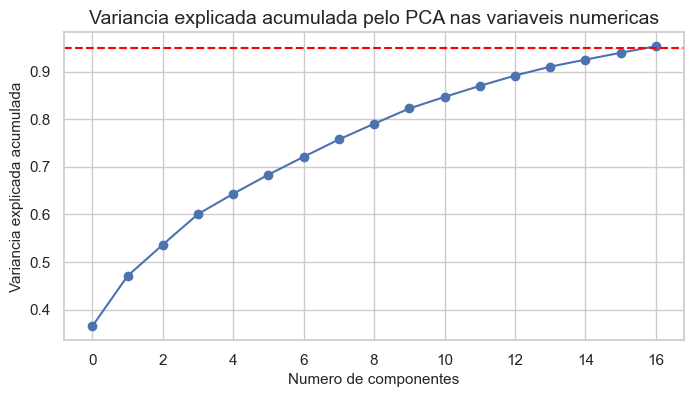

In [29]:
numeric_pca = pca_fitted.named_steps['preprocessor'].named_transformers_['num'].named_steps['pca']
print('Numero de componentes principais:', numeric_pca.n_components_)
print('Variancia explicada acumulada:', round(numeric_pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(numeric_pca.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='red', linestyle='--')
plt.title('Variancia explicada acumulada pelo PCA nas variaveis numericas')
plt.xlabel('Numero de componentes')
plt.ylabel('Variancia explicada acumulada')
plt.show()

O melhor modelo após a análise continua sendo o sem PCA e sem remoção considerando VIF